REGIONES Y FRONTERAS

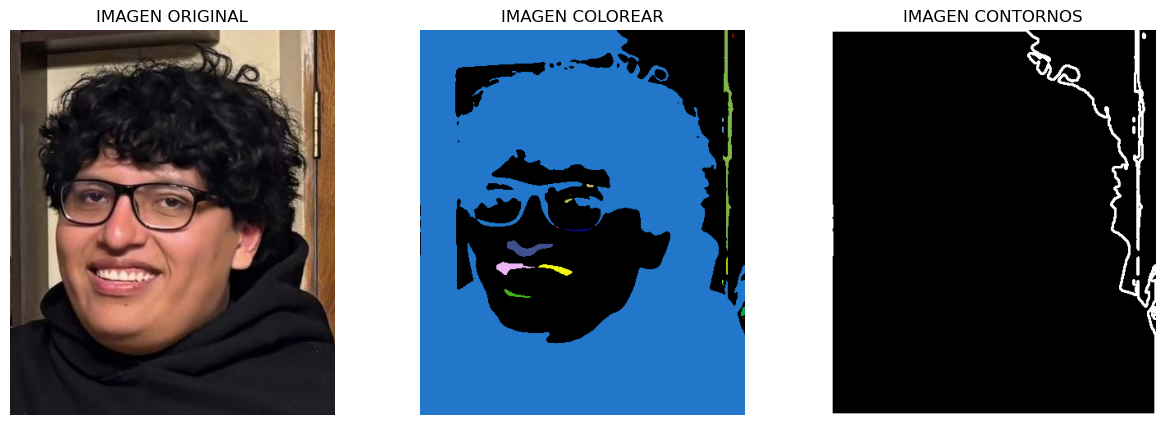

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('PDI2026/Clase1/chanki.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# COMBINACIONES DE TECNICAS PARA PREPARAR LA IMAGEN
blur = cv2.GaussianBlur(gray, (7,7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# ENCONTRAMOS LAS REGIONES
num_l, label = cv2.connectedComponents(binary)

# IDENTIFICAMOS POR COLORES
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)

# FONDO NEGRO
color[0] = [0,0,0]
colorear = color[label]

# ENCONTRAR FRONTERAS
contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.title("IMAGEN ORIGINAL")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(132)
plt.title("IMAGEN COLOREAR")
plt.imshow(colorear)
plt.axis('off')

plt.subplot(133)
plt.title("IMAGEN CONTORNOS")
plt.imshow(contornos_fin, cmap='gray')
plt.axis('off')

plt.show()

CONTEO

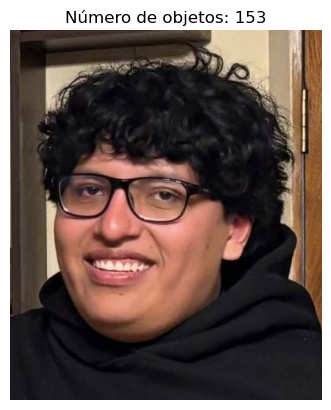

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binario = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # Componentes conectados de OpenCV
    num_labels, labels = cv2.connectedComponents(binario)
    num_obj = num_labels - 1
    return num_obj

imagen = cv2.imread('PDI2026/Clase1/chanki.jpg')
conteo = contar_elementos(imagen)

# Convertir a RGB para mostrar correctamente
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.imshow(imagen_rgb)
plt.title(f'Número de objetos: {conteo}')
plt.axis('off')
plt.show()

PRACTICA ADOLFO VERA
Practica con los 2 codigos que se hizo en clases

TOTAL REGIONES: 19

REGION 01: COLOR RGB(196, 075, 239) - PIXELES: 125129
REGION 02: COLOR RGB(111, 088, 251) - PIXELES:   1054
REGION 03: COLOR RGB(065, 252, 034) - PIXELES:     14
REGION 04: COLOR RGB(113, 095, 076) - PIXELES:      3
REGION 05: COLOR RGB(216, 016, 212) - PIXELES:      9
REGION 06: COLOR RGB(011, 158, 119) - PIXELES:     15
REGION 07: COLOR RGB(178, 231, 049) - PIXELES:     27
REGION 08: COLOR RGB(060, 071, 093) - PIXELES:      1
REGION 09: COLOR RGB(055, 220, 162) - PIXELES:     26
REGION 10: COLOR RGB(045, 064, 229) - PIXELES:      3
REGION 11: COLOR RGB(240, 005, 031) - PIXELES:     71
REGION 12: COLOR RGB(170, 195, 224) - PIXELES:    500
REGION 13: COLOR RGB(137, 001, 219) - PIXELES:     41
REGION 14: COLOR RGB(196, 153, 010) - PIXELES:    316
REGION 15: COLOR RGB(253, 145, 110) - PIXELES:    224
REGION 16: COLOR RGB(078, 095, 239) - PIXELES:      9
REGION 17: COLOR RGB(179, 025, 059) - PIXELES:    108
REGION 18: COLOR RGB(201, 211, 078) - PIXELES:     44
REGION 1

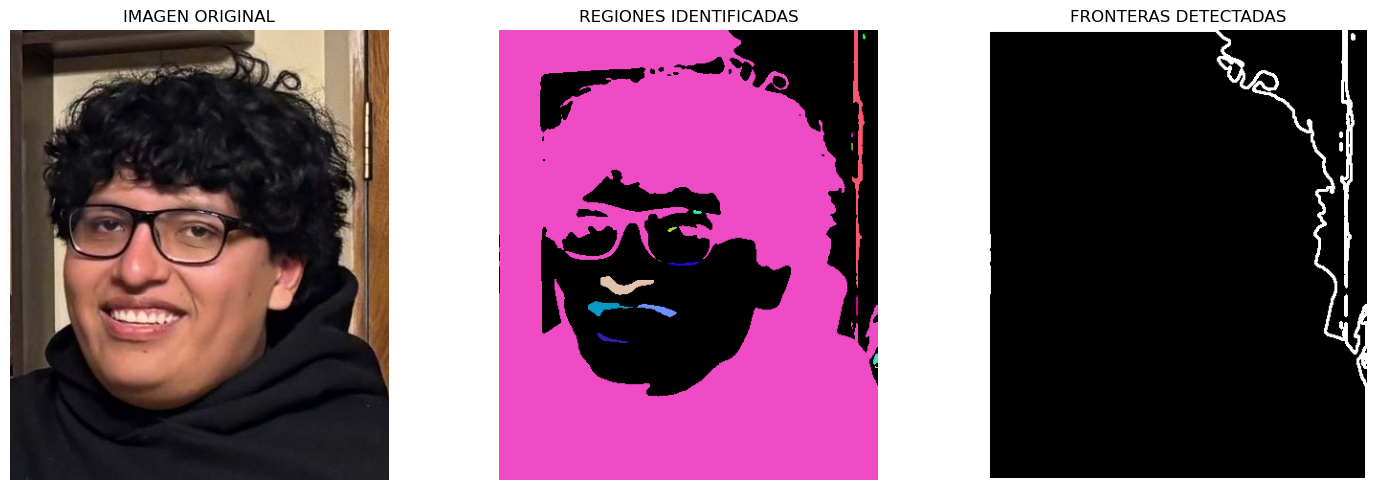

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analizar_regiones(imagen):
    gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    
    # Suavizado y umbralización
    suave = cv2.GaussianBlur(gris, (7,7), 0)
    _, binaria = cv2.threshold(suave, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Etiquetar regiones conectadas
    num_etiquetas, etiquetas = cv2.connectedComponents(binaria)
    num_regiones = num_etiquetas - 1  # Fondo
    
    return etiquetas, num_regiones, binaria, gris

def visualizar_resultados(imagen_original, etiquetas, num_regiones, binaria, gris):
    # Colores aleatorios para cada región
    colores = np.random.randint(0, 255, size=(num_regiones + 1, 3), dtype=np.uint8)
    colores[0] = [0, 0, 0]  # Fondo negro
    
    # Colorear cada región
    imagen_coloreada = np.zeros_like(imagen_original)
    for i in range(1, num_regiones + 1):
        mascara = (etiquetas == i)
        imagen_coloreada[mascara] = colores[i]
    
    # Encontrar contornos
    contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    imagen_contornos = cv2.drawContours(np.zeros_like(gris), contornos, -1, 255, 2)
    
    # Contar elementos por región
    total_pixeles = 0
    print(f'TOTAL REGIONES: {num_regiones}\n')
    
    for region_id in range(1, num_regiones + 1):
        color_region = colores[region_id]
        cantidad_pixeles = np.sum(etiquetas == region_id)
        total_pixeles += cantidad_pixeles
        
        print(f'REGION {region_id:02d}: COLOR RGB({color_region[0]:03d}, {color_region[1]:03d}, {color_region[2]:03d}) - PIXELES: {cantidad_pixeles:6d}')
    
    print(f'\nTOTAL PIXELES EN TODAS LAS REGIONES: {total_pixeles}\n')
    
    return imagen_coloreada, imagen_contornos

# Cargar y procesar imagen
imagen = cv2.imread('PDI2026/Clase1/chanki.jpg')
etiquetas, num_regiones, binaria, gris = analizar_regiones(imagen)
imagen_coloreada, imagen_contornos = visualizar_resultados(imagen, etiquetas, num_regiones, binaria, gris)

# Resultados
plt.figure(figsize=(15,5))

plt.subplot(131)
plt.title("IMAGEN ORIGINAL")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(132)
plt.title("REGIONES IDENTIFICADAS")
plt.imshow(cv2.cvtColor(imagen_coloreada, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(133)
plt.title("FRONTERAS DETECTADAS")
plt.imshow(imagen_contornos, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()